# Code sequence comparison: normal vs anomaly (fan)

Load Stage 1 VQ-VAE and fan test set; stratify by machine ID; encode normal and anomalous clips to discrete code indices (fine and coarse); compute the **fraction of code positions that differ** between anomaly and normal. If anomalous clips map to nearly identical code sequences as normal clips, the architecture has a train/inference mismatch (Stage 2 sees no "wrong" codes to correct).

## 1. Setup and paths

In [5]:
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt

# Project root for src imports
_cwd = Path(".").resolve()
PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_PATH = Path("/mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset")
CKPT_DIR = PROJECT_ROOT / "checkpoints"
MACHINE_TYPE = "fan"
BATCH_SIZE = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Stage 1 checkpoint (multi-type or fan-only)
STAGE1_CKPT = CKPT_DIR / "stage1" / "ToyCar+ToyConveyor+fan+pump+slider+valve" / "checkpoints_trainandtest_emb128_64_hid256_128_fine1024_coarse512_iter20000_bs256_stage1_ToyCar+ToyConveyor+fan+pump+slider+valve_best.pt"
if not STAGE1_CKPT.exists():
    STAGE1_CKPT = CKPT_DIR / "stage1" / MACHINE_TYPE / f"stage1_{MACHINE_TYPE}_best.pt"

print(f"Device: {DEVICE}")
print(f"Stage1 checkpoint: {STAGE1_CKPT}")
print(f"Data path: {DATA_PATH}")

Device: cuda
Stage1 checkpoint: /home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR/checkpoints/stage1/ToyCar+ToyConveyor+fan+pump+slider+valve/checkpoints_trainandtest_emb128_64_hid256_128_fine1024_coarse512_iter20000_bs256_stage1_ToyCar+ToyConveyor+fan+pump+slider+valve_best.pt
Data path: /mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset


## 2. Load Stage 1 model and datasets

In [7]:
from src.data.dataset import DCASE2020Task2LogMelDataset, DCASE2020Task2TestDataset
from src.models.vq_vae.autoencoders import VQ_VAE_2Layer
from src.utils.checkpoint_compat import migrate_vq_vae_state_dict

ckpt = torch.load(STAGE1_CKPT, map_location="cpu", weights_only=True)

n_mels, T = 128, 320
test_ds = DCASE2020Task2TestDataset(
    root=str(DATA_PATH),
    machine_type=MACHINE_TYPE,
    target_T=T,
)

num_embeddings_coarse = ckpt["num_embeddings_coarse"]
num_embeddings_fine = ckpt["num_embeddings_fine"]
embedding_dim_coarse = ckpt["embedding_dim_coarse"]
embedding_dim_fine = ckpt["embedding_dim_fine"]
hidden_channels_coarse = ckpt["hidden_channels_coarse"]
hidden_channels_fine = ckpt["hidden_channels_fine"]
num_residual_layers = ckpt["num_residual_layers"]

vq_vae = VQ_VAE_2Layer(
    hidden_channels=(hidden_channels_coarse, hidden_channels_fine),
    num_residual_layers=num_residual_layers,
    num_embeddings=(num_embeddings_coarse, num_embeddings_fine),
    embedding_dim=(embedding_dim_coarse, embedding_dim_fine),
    commitment_cost=0.25,
    decay=0.95,
)
state = dict(ckpt["model_state_dict"])
migrate_vq_vae_state_dict(state)
vq_vae.load_state_dict(state)
vq_vae = vq_vae.eval().to(DEVICE)

print(f"n_mels={n_mels}, T={T}")
print(f"Test clips: {len(test_ds)}")

DCASE2020Task2TestDataset: fan | 1875 clips | IDs: ['id_00', 'id_02', 'id_04', 'id_06']
n_mels=128, T=320
Test clips: 1875


## 3. Stratify test set by machine_id and label

In [8]:
grouped = defaultdict(lambda: {0: [], 1: []})
for idx in range(len(test_ds)):
    spec, label, machine_id = test_ds[idx]
    if spec.dim() == 3:
        spec = spec.unsqueeze(0)
    grouped[machine_id][label].append((spec, idx))

for mid in sorted(grouped.keys()):
    n_norm = len(grouped[mid][0])
    n_anom = len(grouped[mid][1])
    print(f"{mid}: normal={n_norm}, anomaly={n_anom}")

id_00: normal=100, anomaly=407
id_02: normal=100, anomaly=359
id_04: normal=100, anomaly=348
id_06: normal=100, anomaly=361


## 4. Encode to discrete indices (fine and coarse)

In [9]:
def encode_specs_to_indices(vq_vae, spec_list, device, batch_size=32):
    """Stack specs, batch, run encode_to_indices; return (indices_coarse, indices_fine)."""
    if not spec_list:
        return None, None
    specs = torch.cat([s[0] for s in spec_list], dim=0)
    all_coarse, all_fine = [], []
    for i in range(0, specs.shape[0], batch_size):
        batch = specs[i : i + batch_size].to(device)
        with torch.no_grad():
            idx_c, idx_f = vq_vae.encode_to_indices(batch)
        all_coarse.append(idx_c.cpu())
        all_fine.append(idx_f.cpu())
    return torch.cat(all_coarse, dim=0), torch.cat(all_fine, dim=0)

results = {}
for mid in sorted(grouped.keys()):
    norm_list = grouped[mid][0]
    anom_list = grouped[mid][1]
    norm_coarse, norm_fine = encode_specs_to_indices(vq_vae, norm_list, DEVICE, BATCH_SIZE)
    anom_coarse, anom_fine = encode_specs_to_indices(vq_vae, anom_list, DEVICE, BATCH_SIZE)
    results[mid] = {
        "normal_coarse": norm_coarse,
        "normal_fine": norm_fine,
        "anomaly_coarse": anom_coarse,
        "anomaly_fine": anom_fine,
        "n_normal": len(norm_list),
        "n_anomaly": len(anom_list),
    }

print("Encoded. Shapes (example):", results[sorted(results.keys())[0]]["normal_fine"].shape)

Encoded. Shapes (example): torch.Size([100, 32, 80])


## 5. Reference normal (mode per position)

In [10]:
def mode_per_position(indices):
    """indices: (N, H, W) long. Return (H, W) mode at each position."""
    N, H, W = indices.shape
    out = torch.empty(H, W, dtype=torch.long)
    for h in range(H):
        for w in range(W):
            out[h, w] = indices[:, h, w].mode().values.item()
    return out

for mid in sorted(results.keys()):
    r = results[mid]
    nc, nf = r["normal_coarse"], r["normal_fine"]
    r["mode_coarse"] = mode_per_position(nc)
    r["mode_fine"] = mode_per_position(nf)

print("Mode reference computed per machine_id.")

Mode reference computed per machine_id.


## 6. Fraction of positions that differ

In [11]:
def frac_differ(indices, mode_ref):
    """indices: (N, H, W), mode_ref: (H, W). Return (N,) fraction per sample."""
    diff = (indices != mode_ref.unsqueeze(0)).float()
    return diff.view(diff.shape[0], -1).mean(dim=1)

rows = []
for mid in sorted(results.keys()):
    r = results[mid]
    mc, mf = r["mode_coarse"], r["mode_fine"]
    ac, af = r["anomaly_coarse"], r["anomaly_fine"]
    nc, nf = r["normal_coarse"], r["normal_fine"]

    frac_anom_fine = frac_differ(af, mf)
    frac_anom_coarse = frac_differ(ac, mc)
    frac_norm_fine = frac_differ(nf, mf)
    frac_norm_coarse = frac_differ(nc, mc)

    r["frac_anom_fine"] = frac_anom_fine
    r["frac_anom_coarse"] = frac_anom_coarse
    r["frac_norm_fine"] = frac_norm_fine
    r["frac_norm_coarse"] = frac_norm_coarse

    rows.append({
        "machine_id": mid,
        "n_normal": r["n_normal"],
        "n_anomaly": r["n_anomaly"],
        "mean_frac_differ_fine_anom": frac_anom_fine.mean().item(),
        "mean_frac_differ_coarse_anom": frac_anom_coarse.mean().item(),
        "mean_frac_differ_fine_normal": frac_norm_fine.mean().item(),
        "mean_frac_differ_coarse_normal": frac_norm_coarse.mean().item(),
    })

import pandas as pd
df = pd.DataFrame(rows)
df

,machine_id,n_normal,n_anomaly,mean_frac_differ_fine_anom,mean_frac_differ_coarse_anom,mean_frac_differ_fine_normal,mean_frac_differ_coarse_normal
0,id_00,100,407,0.996543,0.990464,0.973012,0.962828
1,id_02,100,359,0.997336,0.992292,0.973043,0.963969
2,id_04,100,348,0.996633,0.989925,0.973457,0.964422
3,id_06,100,361,0.996623,0.990690,0.971613,0.964109


## 7. Summary and interpretation

In [12]:
overall_anom_fine = np.concatenate([results[mid]["frac_anom_fine"].numpy() for mid in sorted(results.keys())])
overall_anom_coarse = np.concatenate([results[mid]["frac_anom_coarse"].numpy() for mid in sorted(results.keys())])
overall_norm_fine = np.concatenate([results[mid]["frac_norm_fine"].numpy() for mid in sorted(results.keys())])
overall_norm_coarse = np.concatenate([results[mid]["frac_norm_coarse"].numpy() for mid in sorted(results.keys())])

print("Overall (all machine IDs):")
print(f"  Anomaly vs normal  - fine:  mean frac differ = {overall_anom_fine.mean():.4f} (std={overall_anom_fine.std():.4f})")
print(f"  Anomaly vs normal  - coarse: mean frac differ = {overall_anom_coarse.mean():.4f} (std={overall_anom_coarse.std():.4f})")
print(f"  Normal vs normal   - fine:  mean frac differ = {overall_norm_fine.mean():.4f} (baseline)")
print(f"  Normal vs normal   - coarse: mean frac differ = {overall_norm_coarse.mean():.4f} (baseline)")
print()
if overall_anom_fine.mean() <= overall_norm_fine.mean() + 0.05 and overall_anom_coarse.mean() <= overall_norm_coarse.mean() + 0.05:
    print("Interpretation: Anomaly fractions are close to baseline. The encoder may be mapping anomalous clips to nearly the same code sequences as normal (train/inference mismatch).")
else:
    print("Interpretation: Anomaly fractions are clearly higher than baseline. The encoder does separate anomaly from normal in code space.")

Overall (all machine IDs):
  Anomaly vs normal  - fine:  mean frac differ = 0.9968 (std=0.0014)
  Anomaly vs normal  - coarse: mean frac differ = 0.9908 (std=0.0060)
  Normal vs normal   - fine:  mean frac differ = 0.9728 (baseline)
  Normal vs normal   - coarse: mean frac differ = 0.9638 (baseline)

Interpretation: Anomaly fractions are close to baseline. The encoder may be mapping anomalous clips to nearly the same code sequences as normal (train/inference mismatch).


## 8. Histograms and spatial map (per machine_id)

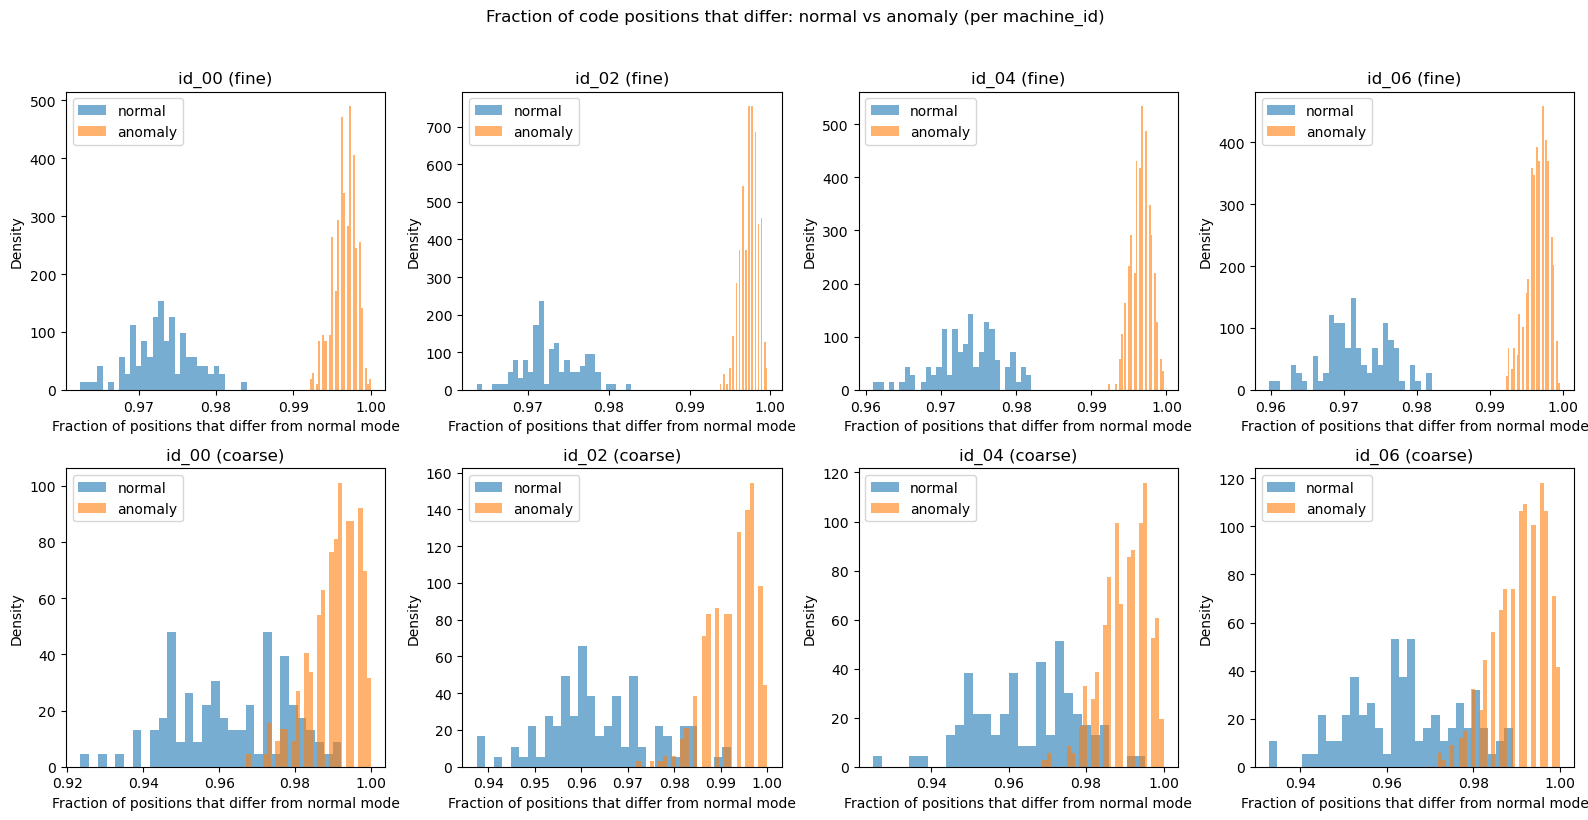

In [13]:
machine_ids = sorted(results.keys())
fig, axes = plt.subplots(2, len(machine_ids), figsize=(4 * len(machine_ids), 8), squeeze=False)
for col, mid in enumerate(machine_ids):
    r = results[mid]
    ax_fine, ax_coarse = axes[0, col], axes[1, col]
    ax_fine.hist(r["frac_norm_fine"].numpy(), bins=30, alpha=0.6, label="normal", color="C0", density=True)
    ax_fine.hist(r["frac_anom_fine"].numpy(), bins=30, alpha=0.6, label="anomaly", color="C1", density=True)
    ax_fine.set_title(f"{mid} (fine)")
    ax_fine.set_xlabel("Fraction of positions that differ from normal mode")
    ax_fine.legend()
    ax_fine.set_ylabel("Density")
    cbar_ax = None
    ax_coarse.hist(r["frac_norm_coarse"].numpy(), bins=30, alpha=0.6, label="normal", color="C0", density=True)
    ax_coarse.hist(r["frac_anom_coarse"].numpy(), bins=30, alpha=0.6, label="anomaly", color="C1", density=True)
    ax_coarse.set_title(f"{mid} (coarse)")
    ax_coarse.set_xlabel("Fraction of positions that differ from normal mode")
    ax_coarse.legend()
    ax_coarse.set_ylabel("Density")
plt.suptitle("Fraction of code positions that differ: normal vs anomaly (per machine_id)", y=1.02)
plt.tight_layout()
plt.show()

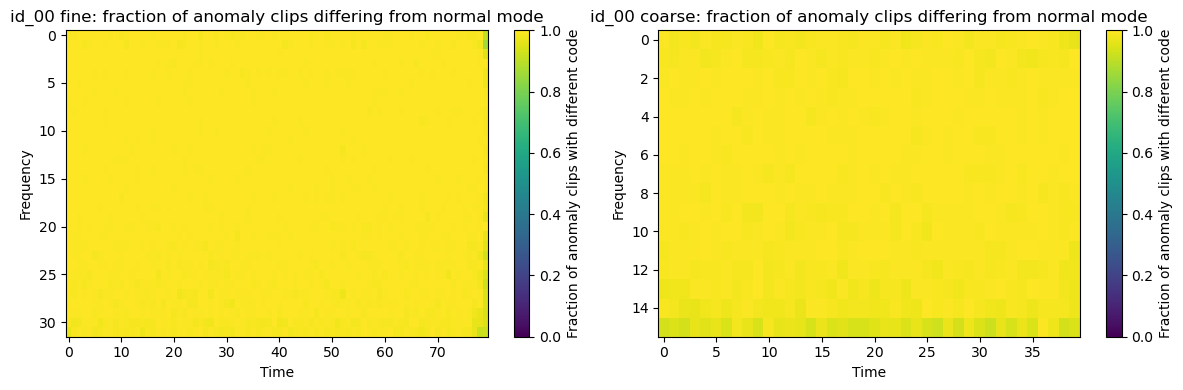

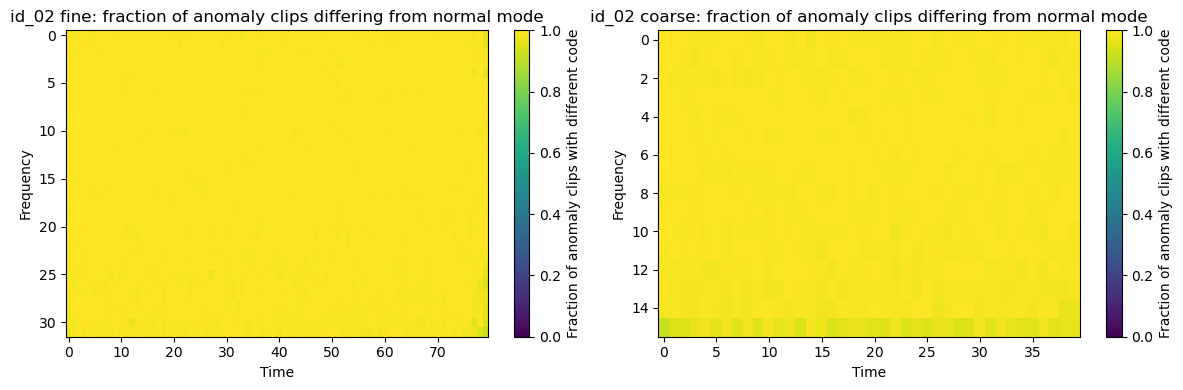

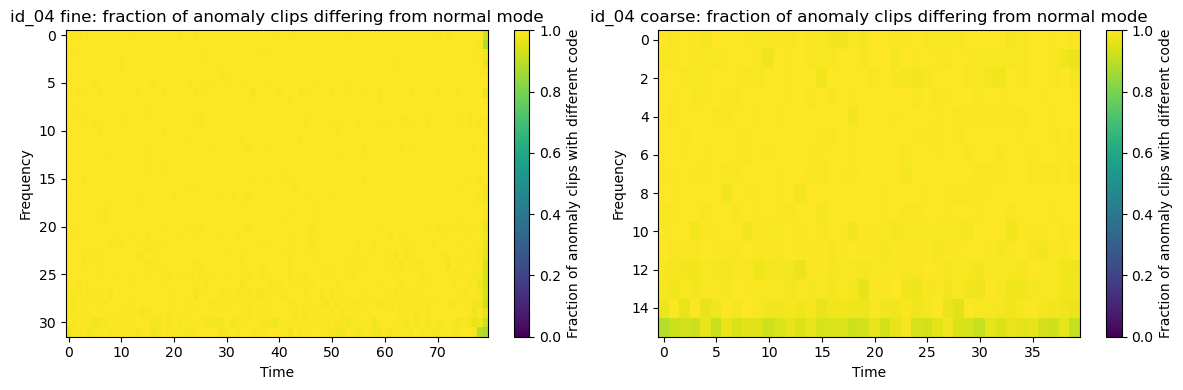

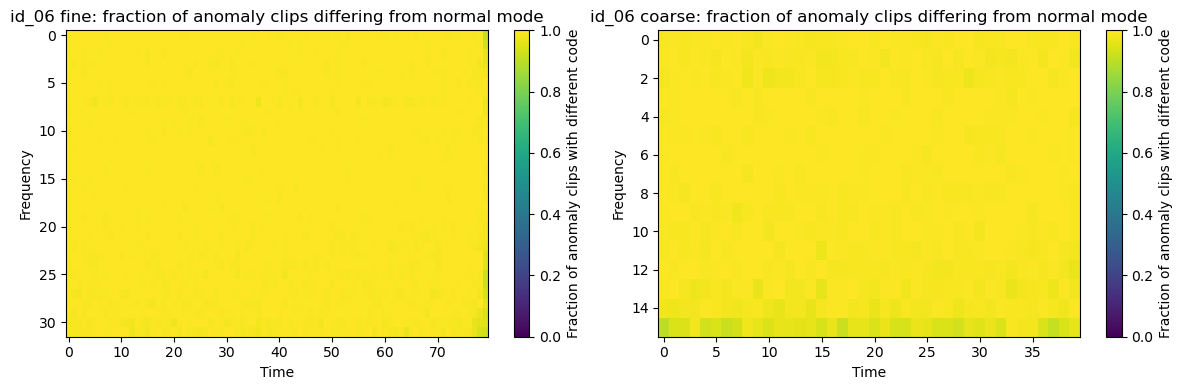

In [14]:
def spatial_differ_fraction(anomaly_indices, mode_ref):
    """anomaly_indices: (N, H, W). At each (h,w), fraction of anomaly clips that differ from mode_ref."""
    diff = (anomaly_indices != mode_ref.unsqueeze(0)).float()
    return diff.mean(dim=0).numpy()

for mid in sorted(results.keys()):
    r = results[mid]
    map_fine = spatial_differ_fraction(r["anomaly_fine"], r["mode_fine"])
    map_coarse = spatial_differ_fraction(r["anomaly_coarse"], r["mode_coarse"])
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    im0 = axes[0].imshow(map_fine, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    axes[0].set_title(f"{mid} fine: fraction of anomaly clips differing from normal mode")
    axes[0].set_xlabel("Time")
    axes[0].set_ylabel("Frequency")
    plt.colorbar(im0, ax=axes[0], label="Fraction of anomaly clips with different code")
    im1 = axes[1].imshow(map_coarse, aspect="auto", cmap="viridis", vmin=0, vmax=1)
    axes[1].set_title(f"{mid} coarse: fraction of anomaly clips differing from normal mode")
    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Frequency")
    plt.colorbar(im1, ax=axes[1], label="Fraction of anomaly clips with different code")
    plt.tight_layout()
    plt.show()

## 9. Top 20 codewords: normal vs anomaly

Histogram of usage (count) for the **top 20** most-used codewords (by total count), comparing normal and anomalous samples, stratified by **machine_id** and by **fine** vs **coarse** quantized latent space. X-axis: code index (top 20 by usage).

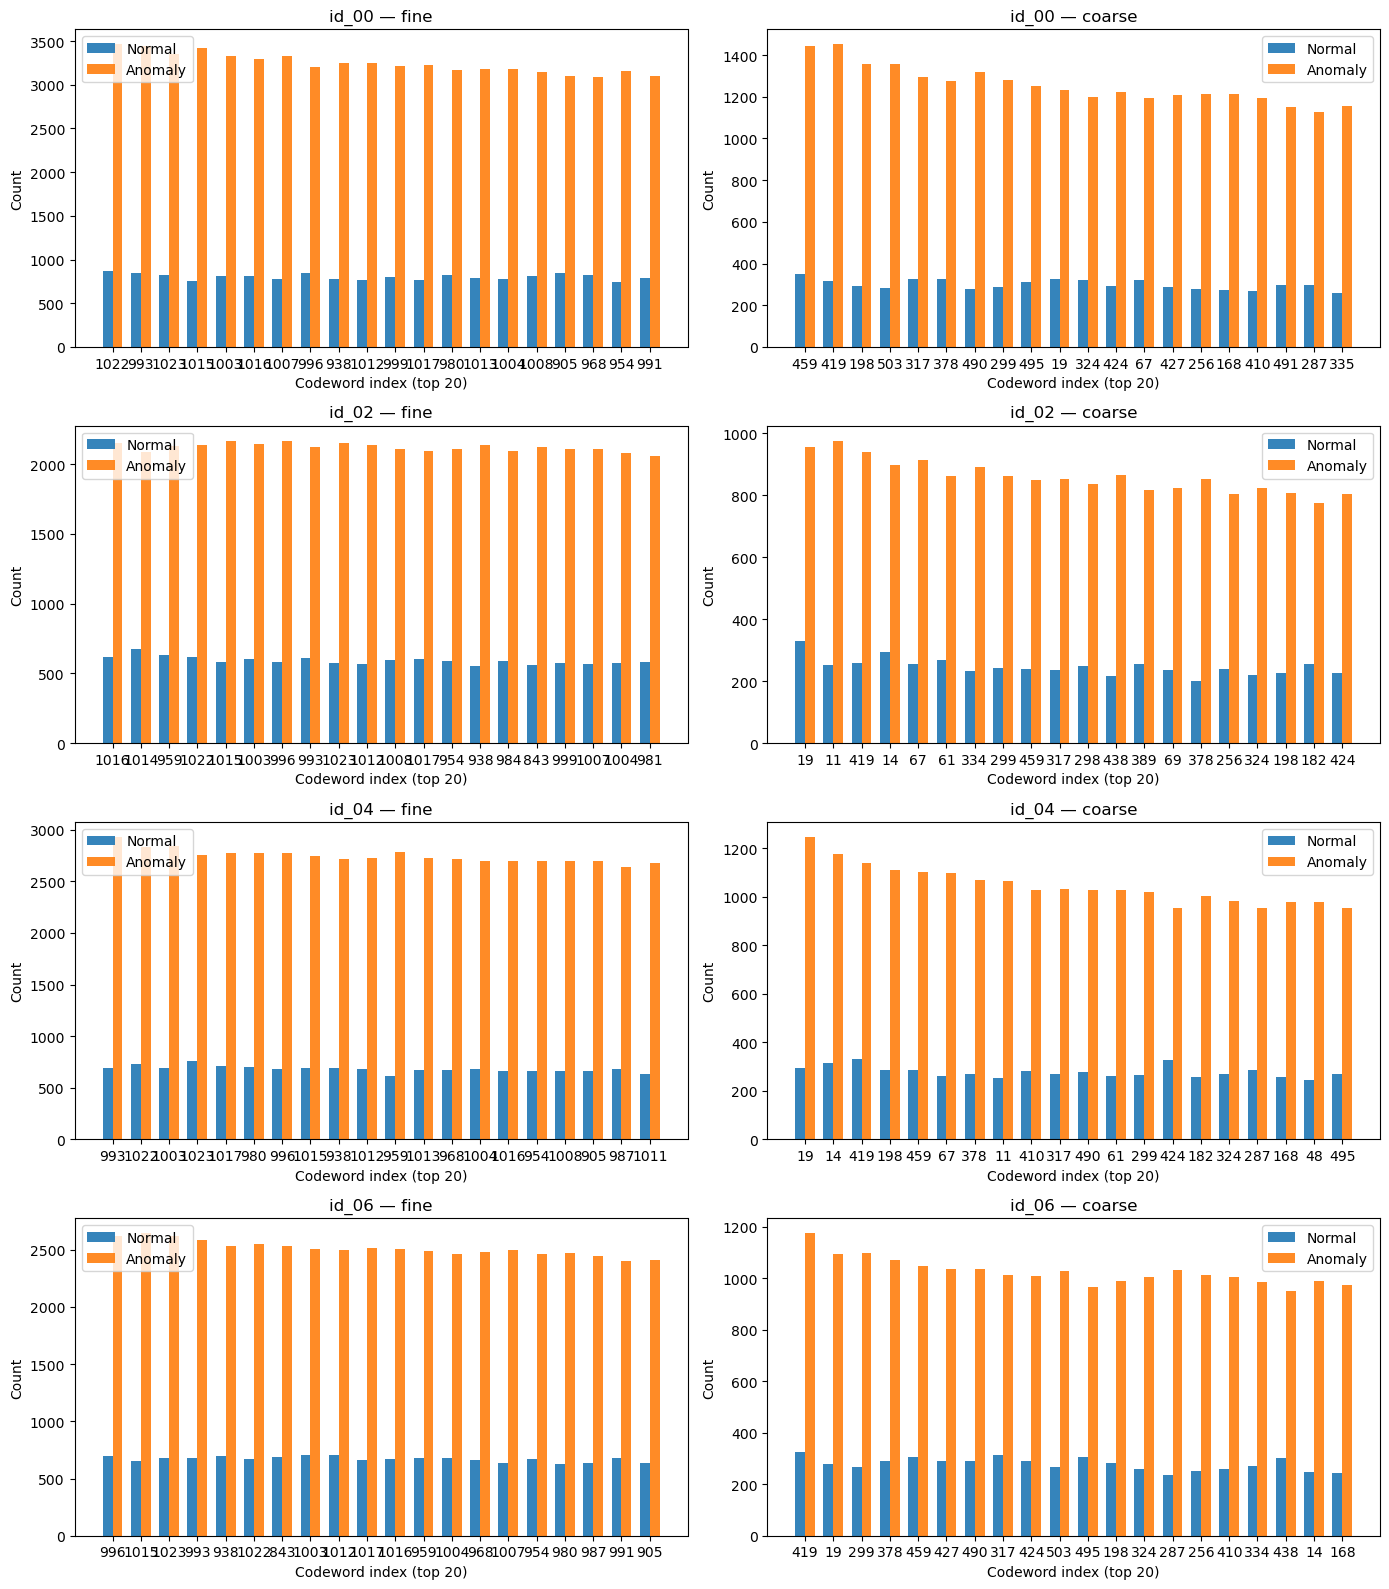

In [15]:
machine_ids = sorted(results.keys())
n_machines = len(machine_ids)
fig, axes = plt.subplots(n_machines, 2, figsize=(14, 4 * n_machines))
if n_machines == 1:
    axes = axes[np.newaxis, :]

for i, mid in enumerate(machine_ids):
    for j, level in enumerate(["fine", "coarse"]):
        ax = axes[i, j]
        norm_flat = results[mid]["normal_" + level].flatten()
        anom_flat = results[mid]["anomaly_" + level].flatten()
        num_codes = int(max(norm_flat.max().item(), anom_flat.max().item()) + 1)
        norm_counts = torch.bincount(norm_flat, minlength=num_codes).numpy()
        anom_counts = torch.bincount(anom_flat, minlength=num_codes).numpy()
        total = norm_counts + anom_counts
        top20_indices = np.argsort(total)[-20:][::-1]
        x = np.arange(20)
        width = 0.35
        ax.bar(x - width/2, norm_counts[top20_indices], width, label="Normal", color="C0", alpha=0.9)
        ax.bar(x + width/2, anom_counts[top20_indices], width, label="Anomaly", color="C1", alpha=0.9)
        ax.set_xlabel("Codeword index (top 20)")
        ax.set_ylabel("Count")
        ax.set_title(f"{mid} — {level}")
        ax.set_xticks(x)
        ax.set_xticklabels([int(k) for k in top20_indices])
        ax.legend()
plt.tight_layout()
plt.show()